In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [15]:
data = pd.read_csv('digit_dataset.csv')
data.head()

,100,0,86.123359,14.294688,80.645161,28.640047,71.24594,42.962438,42.496194,57.131908,25.813492,71.421751,17.711629,85.752633,0.1,100.1,1
0,95.454545,0.0,100.000000,14.334913,100.000000,28.681710,100.000000,43.028506,76.472111,57.293288,50.435065,71.546428,18.181818,85.720817,0.000000,100.0,1.0
1,0.000000,0.0,100.000000,14.273719,100.000000,28.563752,100.000000,42.853784,100.000000,57.143817,100.000000,71.433849,100.000000,85.723882,50.000000,100.0,1.0
2,100.000000,0.0,100.000000,14.300729,60.000000,28.562831,60.000000,42.863561,60.000000,57.164290,40.000000,71.452328,29.420122,85.745898,0.000000,100.0,1.0
3,0.000000,100.0,44.771775,85.872252,66.666667,71.574522,73.517491,57.251163,100.000000,43.008490,100.000000,28.656975,100.000000,14.305460,83.333333,0.0,1.0
4,0.000000,100.0,16.726774,85.751629,33.233831,71.519576,49.139281,57.253180,59.912969,42.895522,72.762132,28.566371,82.896118,14.204190,100.000000,0.0,1.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   100        246 non-null    float64
 1   0          246 non-null    float64
 2   86.123359  246 non-null    float64
 3   14.294688  246 non-null    float64
 4   80.645161  246 non-null    float64
 5   28.640047  246 non-null    float64
 6   71.24594   246 non-null    float64
 7   42.962438  246 non-null    float64
 8   42.496194  246 non-null    float64
 9   57.131908  246 non-null    float64
 10  25.813492  246 non-null    float64
 11  71.421751  246 non-null    float64
 12  17.711629  246 non-null    float64
 13  85.752633  246 non-null    float64
 14  0.1        246 non-null    float64
 15  100.1      246 non-null    float64
 16  1          246 non-null    float64
dtypes: float64(17)
memory usage: 32.8 KB


In [17]:
X = data.iloc[:,:-1]
X.head()

,100,0,86.123359,14.294688,80.645161,28.640047,71.24594,42.962438,42.496194,57.131908,25.813492,71.421751,17.711629,85.752633,0.1,100.1
0,95.454545,0.0,100.000000,14.334913,100.000000,28.681710,100.000000,43.028506,76.472111,57.293288,50.435065,71.546428,18.181818,85.720817,0.000000,100.0
1,0.000000,0.0,100.000000,14.273719,100.000000,28.563752,100.000000,42.853784,100.000000,57.143817,100.000000,71.433849,100.000000,85.723882,50.000000,100.0
2,100.000000,0.0,100.000000,14.300729,60.000000,28.562831,60.000000,42.863561,60.000000,57.164290,40.000000,71.452328,29.420122,85.745898,0.000000,100.0
3,0.000000,100.0,44.771775,85.872252,66.666667,71.574522,73.517491,57.251163,100.000000,43.008490,100.000000,28.656975,100.000000,14.305460,83.333333,0.0
4,0.000000,100.0,16.726774,85.751629,33.233831,71.519576,49.139281,57.253180,59.912969,42.895522,72.762132,28.566371,82.896118,14.204190,100.000000,0.0


In [18]:
y = data.iloc[:,-1]
y.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: 1, dtype: float64

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score,KFold,train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

准确率:  86.0 在k取: 1 的情况下
准确率:  76.0 在k取: 2 的情况下
准确率:  80.0 在k取: 3 的情况下
准确率:  76.0 在k取: 4 的情况下
准确率:  78.0 在k取: 5 的情况下
准确率:  80.0 在k取: 6 的情况下
准确率:  80.0 在k取: 7 的情况下
准确率:  78.0 在k取: 8 的情况下
准确率:  74.0 在k取: 9 的情况下



Text(0, 0.5, '准确率')

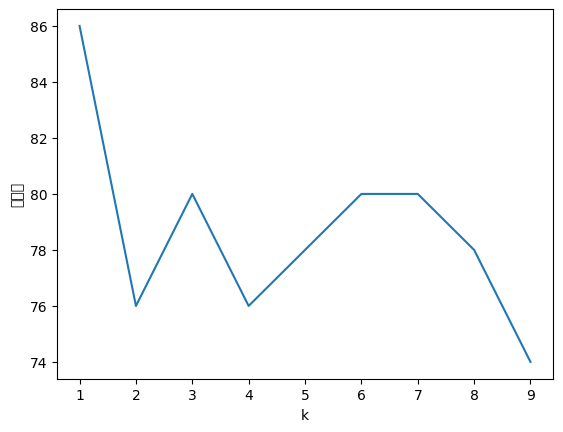

In [43]:
list_k = []
list_acc = []
for k_value in range(1,10):
    list_k.append(k_value)
    model = KNeighborsClassifier(n_neighbors=k_value)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)*100
    list_acc.append(acc)
    print('准确率: ',acc,'在k取:',k_value, '的情况下')
vitri = list_acc.index(max(list_acc))
k = list_k[vitri]
print('')
plt.plot(list_k,list_acc)
plt.xlabel('k')
plt.ylabel('准确率')

In [44]:
model_knn = KNeighborsClassifier(n_neighbors=1)
model_knn.fit(X_train,y_train)
y_pred_knn = model_knn.predict(X_test)
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

         0.0       0.67      0.80      0.73         5
         1.0       1.00      0.50      0.67         4
         2.0       1.00      1.00      1.00         7
         3.0       1.00      0.67      0.80         3
         4.0       0.80      1.00      0.89         4
         5.0       0.80      0.80      0.80         5
         6.0       1.00      0.67      0.80         3
         7.0       0.75      1.00      0.86         3
         8.0       0.83      1.00      0.91        10
         9.0       1.00      0.83      0.91         6

    accuracy                           0.86        50
   macro avg       0.89      0.83      0.84        50
weighted avg       0.88      0.86      0.86        50



In [46]:
from joblib import dump
dump(model_knn, 'knn_model.joblib')

['knn_model.joblib']

<Axes: >

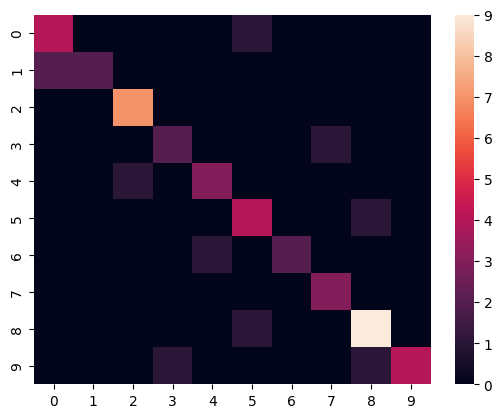

In [38]:
sns.heatmap(confusion_matrix(y_test,y_pred_knn))

In [39]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred_1=clf.predict(X_test)
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80         5
         1.0       0.50      0.50      0.50         4
         2.0       0.88      1.00      0.93         7
         3.0       0.50      0.67      0.57         3
         4.0       0.67      0.50      0.57         4
         5.0       1.00      0.60      0.75         5
         6.0       1.00      0.67      0.80         3
         7.0       1.00      1.00      1.00         3
         8.0       0.71      1.00      0.83        10
         9.0       1.00      0.67      0.80         6

    accuracy                           0.78        50
   macro avg       0.81      0.74      0.76        50
weighted avg       0.81      0.78      0.78        50



<Axes: >

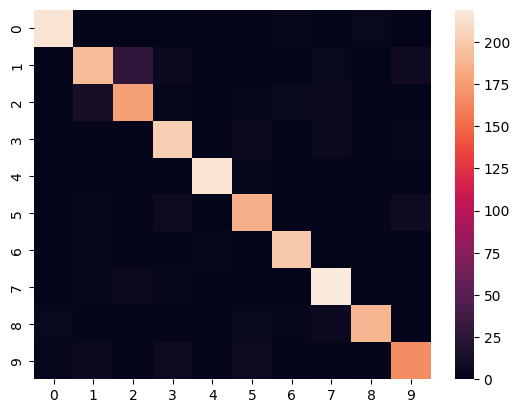

In [15]:
sns.heatmap(confusion_matrix(y_test,y_pred_1))

In [41]:
clf=GaussianNB()
clf.fit(X_train,y_train)
y_pred_1=clf.predict(X_test)
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

         0.0       0.43      0.60      0.50         5
         1.0       1.00      0.50      0.67         4
         2.0       1.00      1.00      1.00         7
         3.0       0.67      0.67      0.67         3
         4.0       0.75      0.75      0.75         4
         5.0       0.50      0.60      0.55         5
         6.0       1.00      0.67      0.80         3
         7.0       1.00      1.00      1.00         3
         8.0       0.75      0.90      0.82        10
         9.0       1.00      0.67      0.80         6

    accuracy                           0.76        50
   macro avg       0.81      0.74      0.75        50
weighted avg       0.80      0.76      0.77        50



<Axes: >

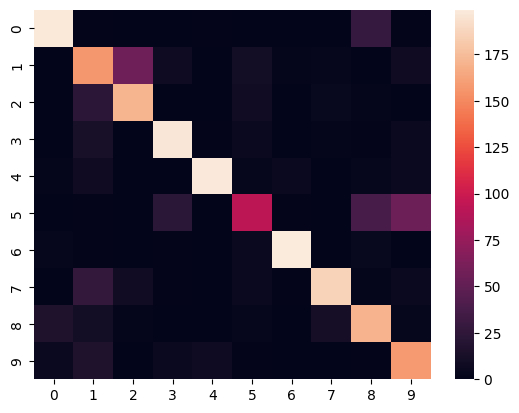

In [17]:
sns.heatmap(confusion_matrix(y_test,y_pred_1))

In [42]:
clf=SVC()
clf.fit(X_train,y_train)
y_pred_1=clf.predict(X_test)
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

         0.0       0.57      0.80      0.67         5
         1.0       1.00      0.50      0.67         4
         2.0       1.00      1.00      1.00         7
         3.0       1.00      0.67      0.80         3
         4.0       0.80      1.00      0.89         4
         5.0       0.50      0.60      0.55         5
         6.0       1.00      0.67      0.80         3
         7.0       1.00      1.00      1.00         3
         8.0       0.90      0.90      0.90        10
         9.0       0.83      0.83      0.83         6

    accuracy                           0.82        50
   macro avg       0.86      0.80      0.81        50
weighted avg       0.85      0.82      0.82        50



<Axes: >

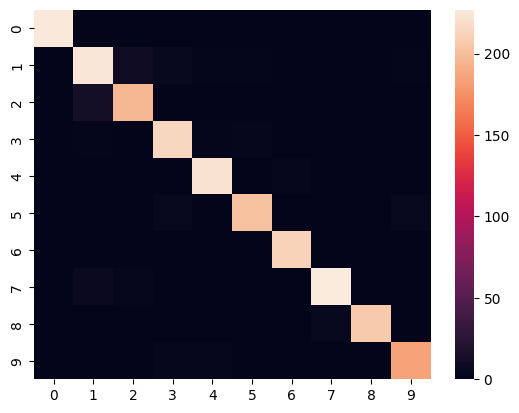

In [19]:
sns.heatmap(confusion_matrix(y_test,y_pred_1))

In [ ]:
# 加载数据
_data = pd.read_csv('digit_dataset.csv', header=None)
_X = data.iloc[:, :-1].values
_y = data.iloc[:, -1].values
